In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#!pip install mlflow pyngrok --quiet
!pip install -q -U mlflow pyngrok

In [3]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.15.1


In [4]:
import os

DB_URI = "sqlite:///mlflow.db"

print(os.getcwd())

/content


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyngrok.ngrok as ngrok
import subprocess
import getpass
import mlflow
import mlflow.sklearn

In [6]:
# 1. Set the experiment name and uri
#mlflow.set_tracking_uri("sqlite:///mlflow.db")
#mlflow.set_experiment("employee_attrition")

In [7]:
!pkill -f "mlflow" || true
!pkill -f "ngrok" || true

^C
^C


In [8]:
import subprocess
import time
import os

# Kill any previous MLflow process
os.system("pkill -f 'mlflow server' || true")

# Start MLflow server on port 5001
log_file = open("/tmp/mlflow.log", "w")

mlflow_process = subprocess.Popen(
    [
        "mlflow",
        "server",
        "--backend-store-uri", "sqlite:///mlflow.db",
        "--host", "0.0.0.0",
        "--port", "5001",
        "--allowed-hosts", "*"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(10)

print("MLflow process:", mlflow_process.poll() is None)

MLflow process: True


In [9]:
!cat /tmp/mlflow.log

Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled. Allowed hosts: *.
2026/08/07 21:42:29 INFO:     Uvicorn running on http://0.0.0.0:5001 (Press CTRL+C to quit)
2026/08/07 21:42:29 INFO:     Started parent process [154081]


In [10]:
!curl http://127.0.0.1:5001

curl: (7) Failed to connect to 127.0.0.1 port 5001 after 0 ms: Connection refused


In [11]:
from pyngrok import ngrok

# Close previous tunnels
ngrok.kill()

# Create new tunnel
tunnel = ngrok.connect(5001, "http")

print("====================================")
print("MLflow URL:")
print(tunnel.public_url)
print("====================================")

MLflow URL:
https://erratic-graceless-regalia.ngrok-free.dev


In [12]:
MLFLOW_URL = "http://127.0.0.1:5001"

mlflow.set_tracking_uri(MLFLOW_URL)

mlflow.set_experiment("employee_attrition")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5001


In [13]:
# NGROK_AUTH_TOKEN = "3HaqleXoPGtIuYwbossJy6Qc4hz_5JUZcdF6BSiGfyhLjbZco"
# !ngrok config add-authtoken {NGROK_AUTH_TOKEN}

# DB_URI = "sqlite:///mlflow.db"
# mlflow.set_tracking_uri(DB_URI)

# # FIX: Add --allowed-hosts "*" to explicitly accept the ngrok domain format
# subprocess.Popen([
#     "mlflow", "ui",
#     "--backend-store-uri", DB_URI,
#     "--port", "5000",
#     "--host", "0.0.0.0",
#     "--allowed-hosts", "*"
# ])

# print("MLflow tracking server restarted with wildcard host permissions.")

# # Securely prompt for your token to protect your account credentials
# print("Enter your ngrok Auth Token:")
# #NGROK_TOKEN = getpass.getpass()

# # Authenticate and spin up the public tunnel
# ngrok.set_auth_token(NGROK_AUTH_TOKEN)
# ngrok_tunnel = ngrok.connect(addr="5000", proto="http")

# print("---" * 15)
# print(f"Click this link to open your MLflow UI: {ngrok_tunnel.public_url}")
# print("---" * 15)

In [14]:
df = pd.read_csv("/content/drive/MyDrive/data_employee_attrition.csv")

In [15]:
df.head() # target feature is Attrition it has values Yes or No so it is classification problem

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [16]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [17]:
df.shape    # rows=1470, columns=35

(1470, 35)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [19]:
num_colmns = df.select_dtypes(include=['number'])
cat_colmns = df.select_dtypes(include=['object'])

In [20]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


'''
By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

'''

In [21]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


#The featute Over18 has only 1 unique value so it will not contribute any thing for prediction, we can drop this feature

In [22]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [23]:
df.isnull().sum()   #There is no missing values present in the dateset

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [24]:
duplicates = df.duplicated().sum()  #There are no duplicates present in the dataset
print(duplicates)

0


In [25]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


# 'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique vale it will not contribute for prediction so we can drop these 3 features

In [26]:
(df['Attrition'].value_counts(normalize=True)*100)/len(['Attrition'])

,proportion
Attrition,
No,83.877551
Yes,16.122449


# #Target feature has an imbalanced data

/tmp/ipykernel_153849/1599895865.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


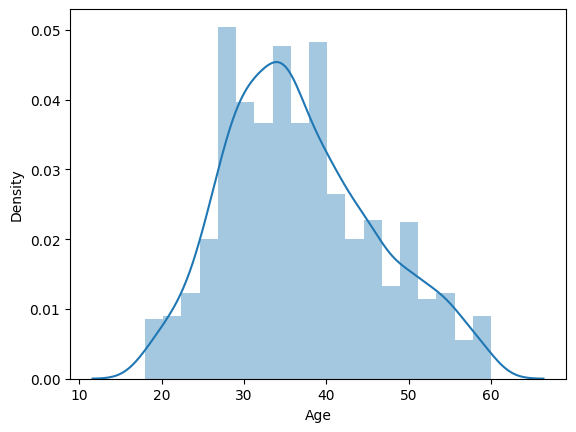

In [27]:
sns.distplot(df['Age'])
plt.show()

<Axes: xlabel='Department'>

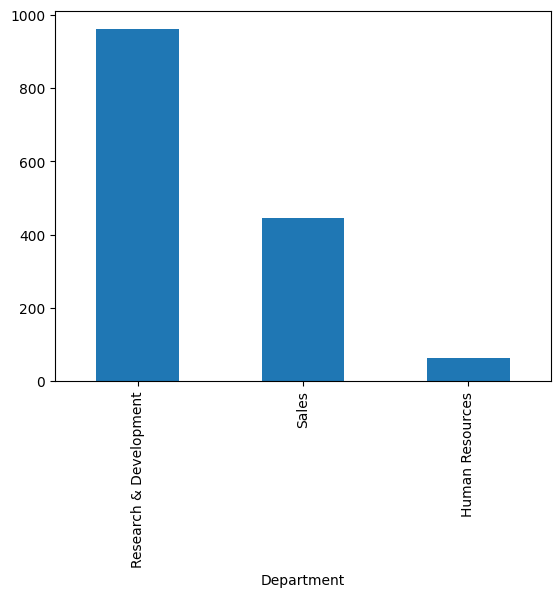

In [28]:
df["Department"].value_counts().plot(kind="bar")

In [29]:
df.corr(numeric_only=True)   # bivariate analysis Numerical vs Numerical

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


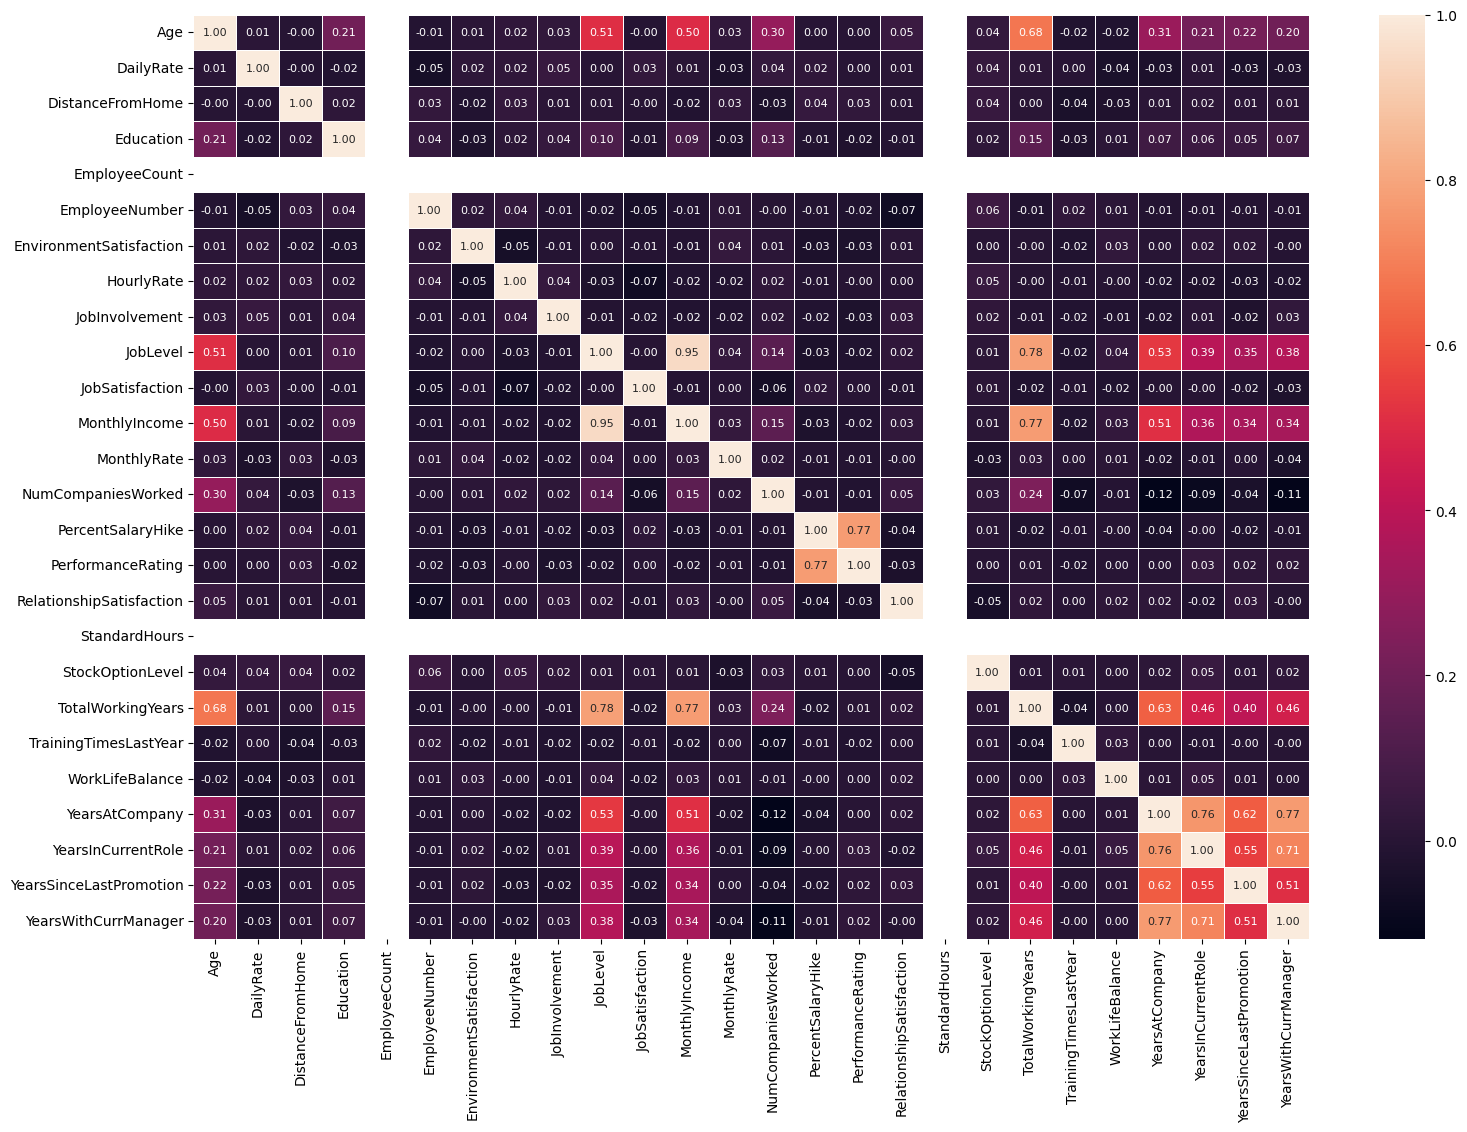

In [30]:
plt.figure(figsize=(18,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size":8})
plt.show()

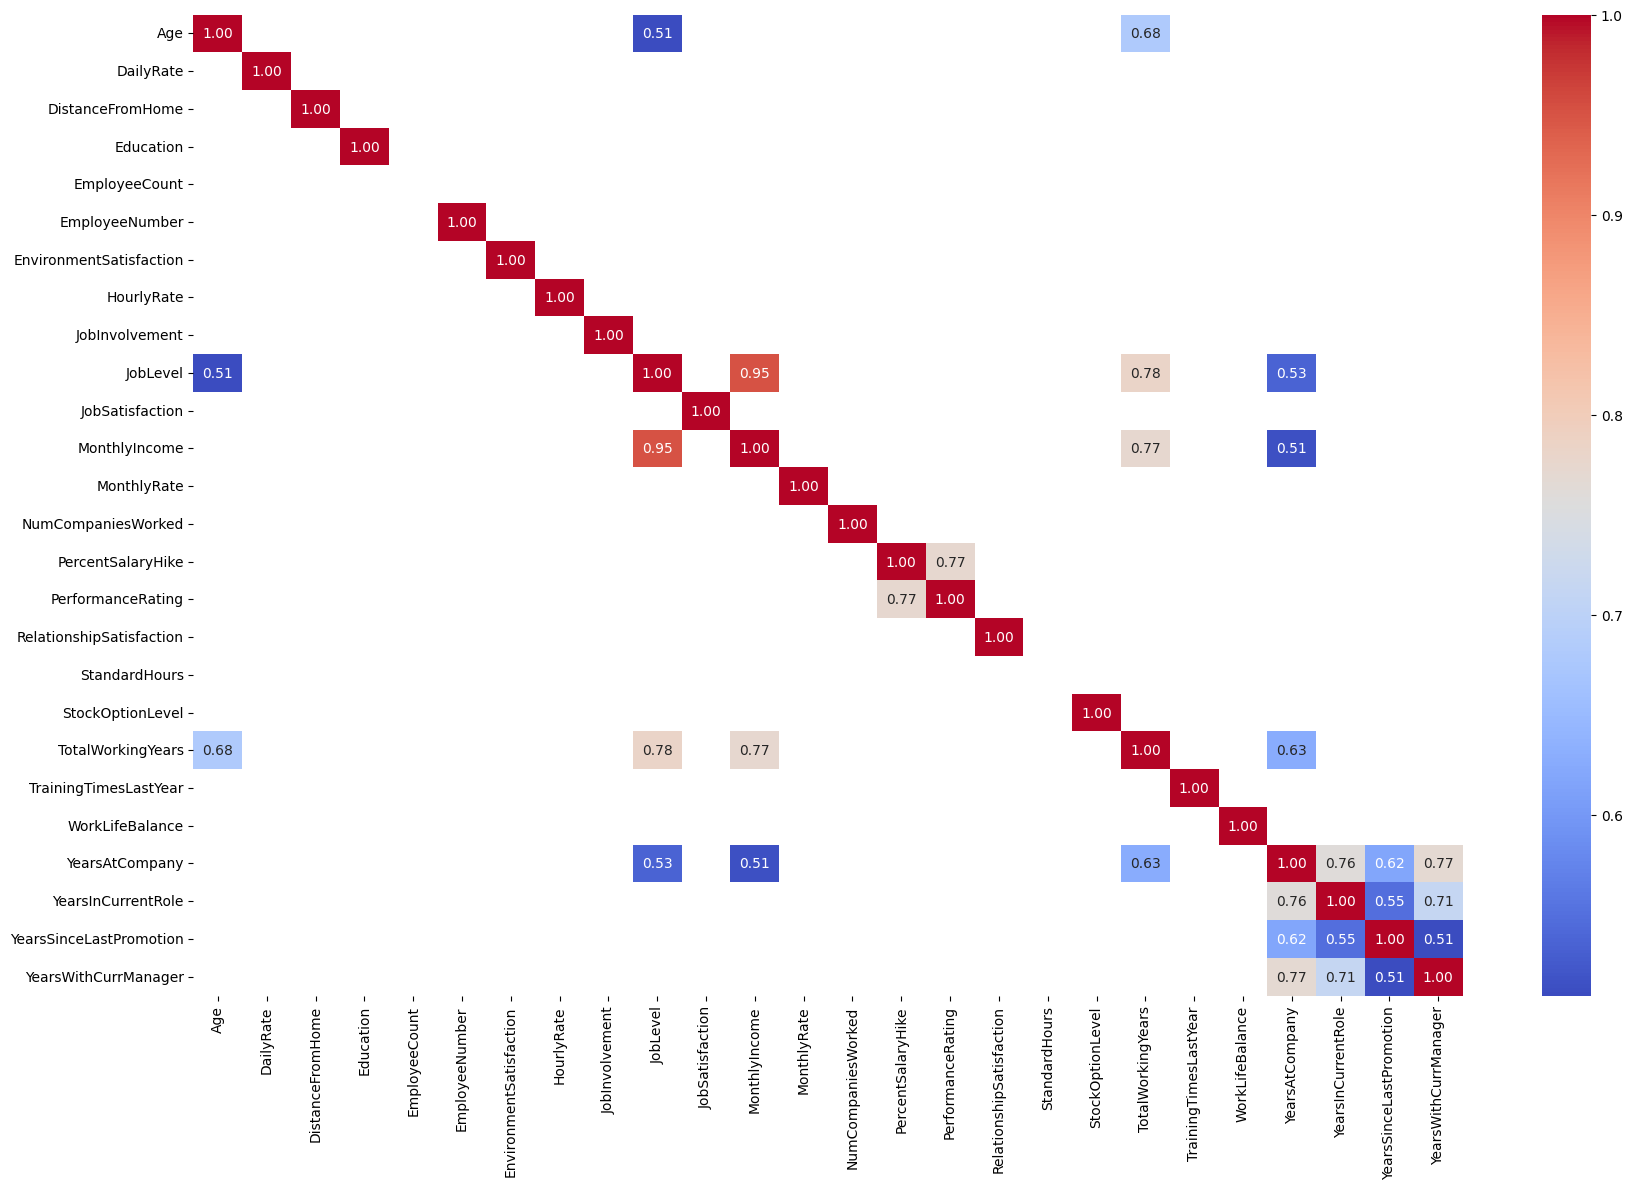

In [31]:
# highly correlated features
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr[(corr.abs() > 0.5)],
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

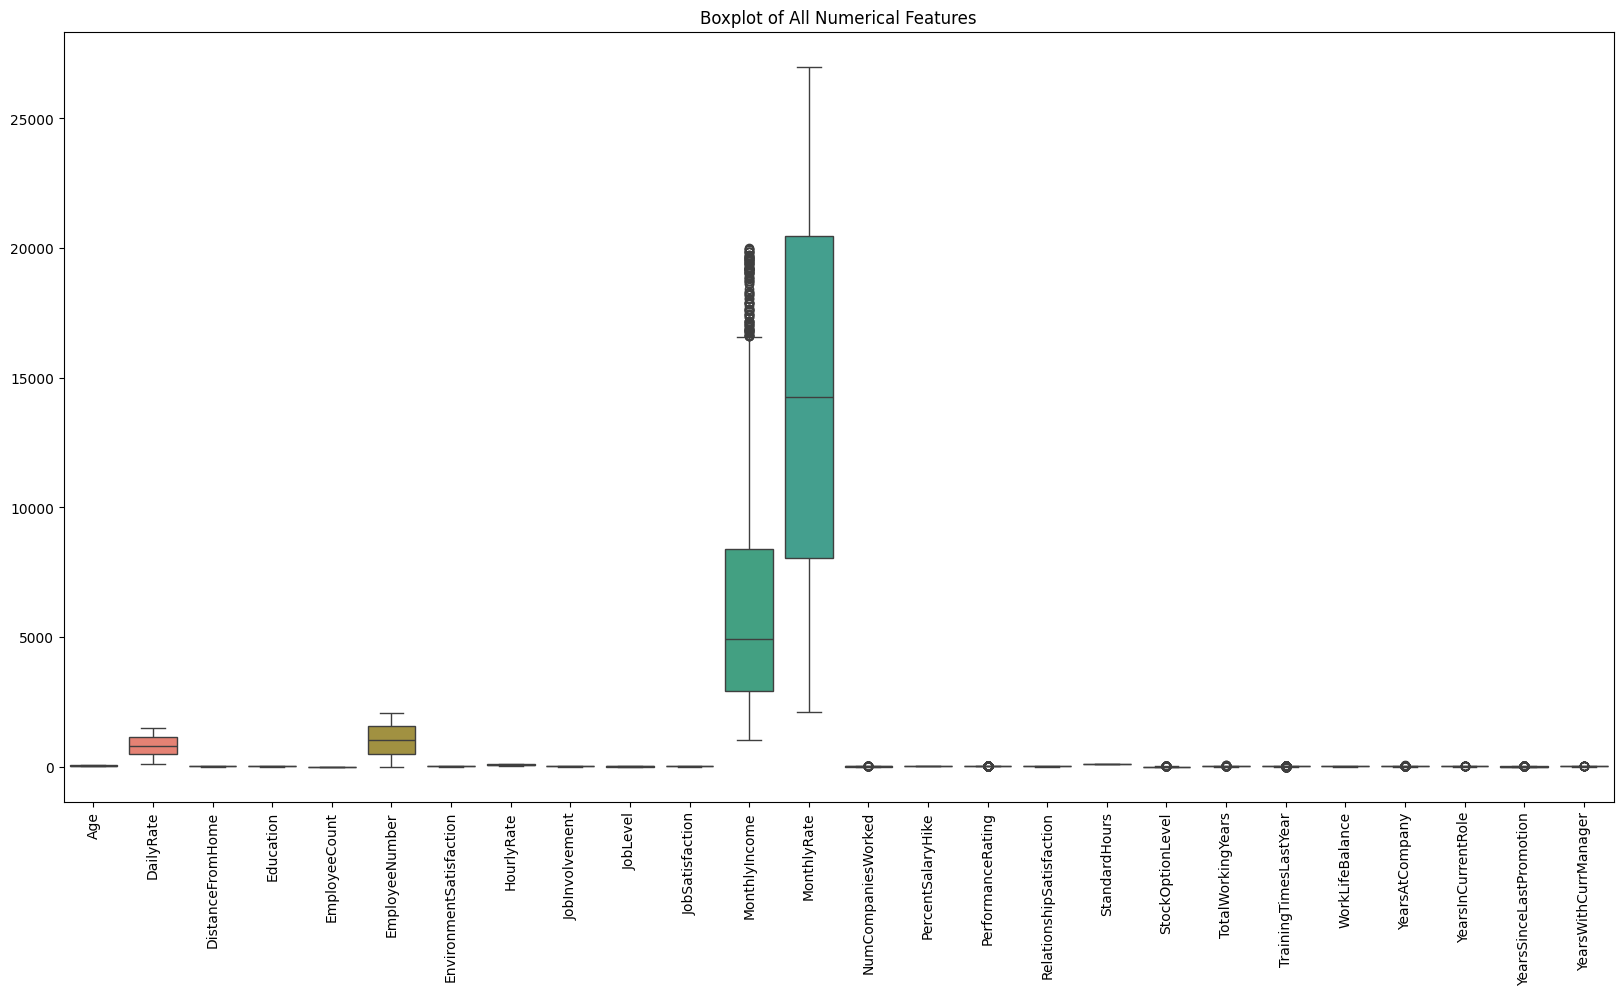

In [32]:
num_colmns = df.select_dtypes(include='number').columns
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[num_colmns])

plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.show()

As per above boxplot observation MonthlyIncome feature has outliers

In [33]:
outlier_summary = []

for col in num_colmns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Outlier Count": count,
        "Outlier %": round((count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("Outlier Count", ascending=False)

,Column,Outlier Count,Outlier %
20,TrainingTimesLastYear,238,16.19
15,PerformanceRating,226,15.37
11,MonthlyIncome,114,7.76
24,YearsSinceLastPromotion,107,7.28
22,YearsAtCompany,104,7.07
18,StockOptionLevel,85,5.78
19,TotalWorkingYears,63,4.29
13,NumCompaniesWorked,52,3.54
23,YearsInCurrentRole,21,1.43
25,YearsWithCurrManager,14,0.95


In [34]:
df.skew(numeric_only=True) # To check skew in the data

,0
Age,0.413286
DailyRate,-0.003519
DistanceFromHome,0.958118
Education,-0.289681
EmployeeCount,0.000000
EmployeeNumber,0.016574
EnvironmentSatisfaction,-0.321654
HourlyRate,-0.032311
JobInvolvement,-0.498419
JobLevel,1.025401


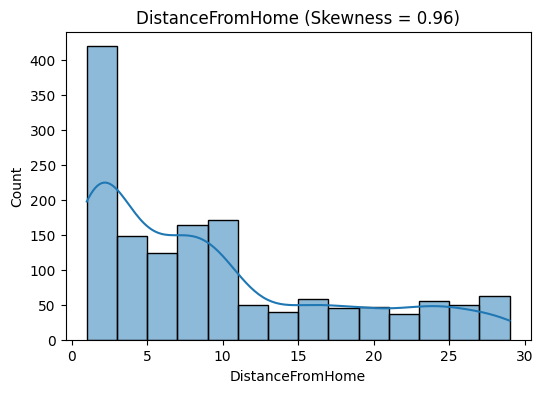

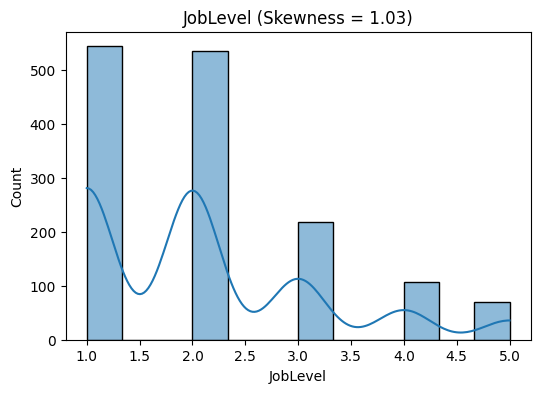

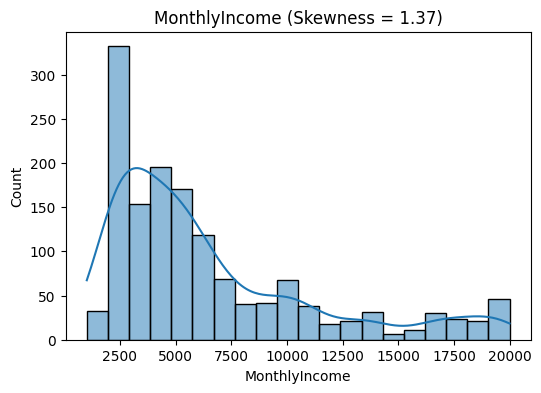

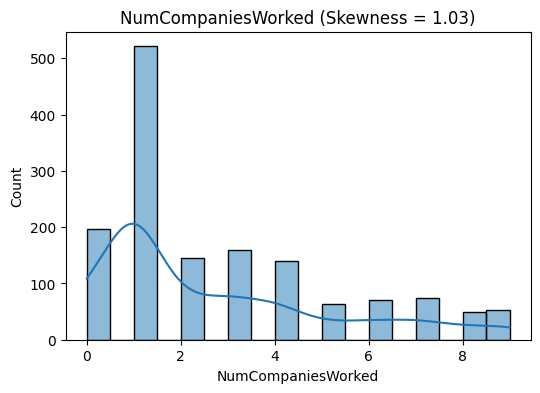

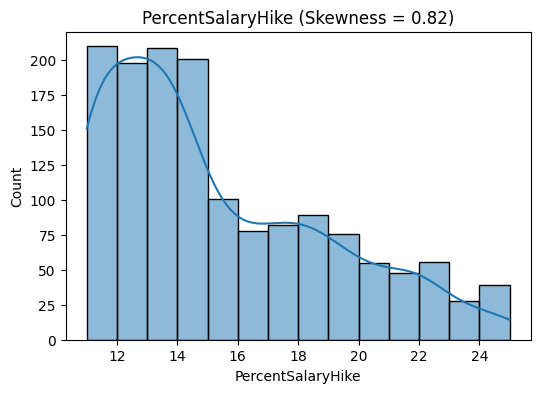

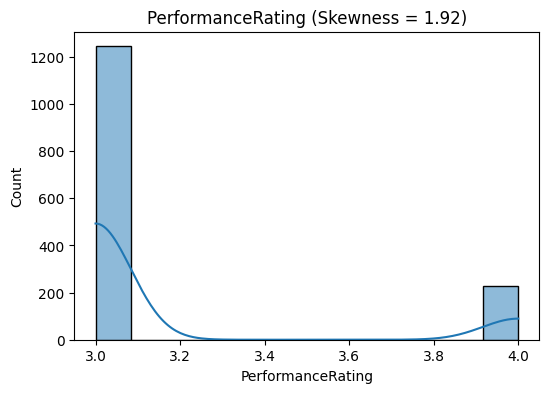

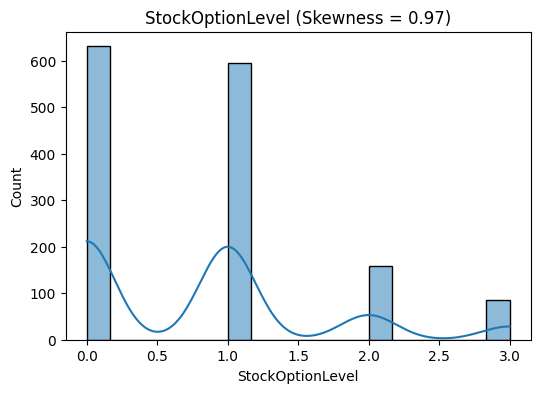

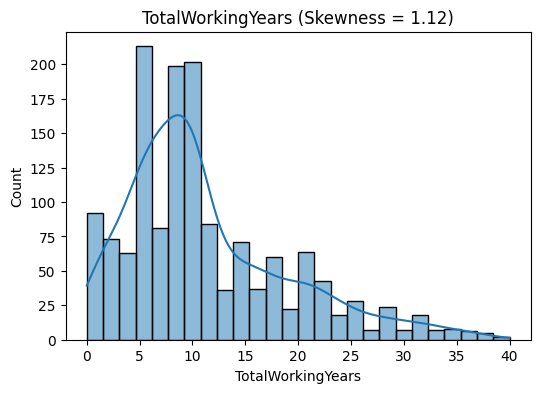

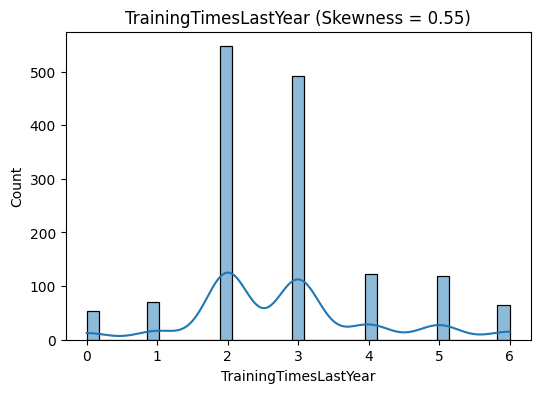

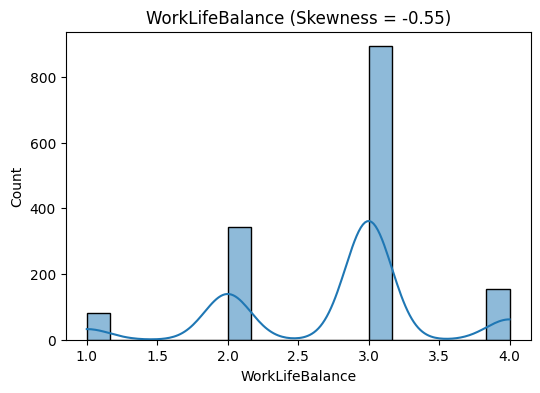

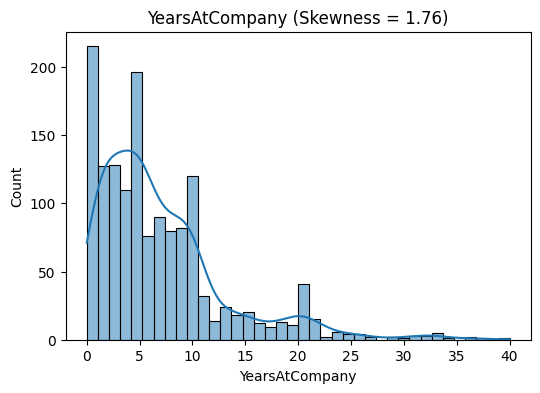

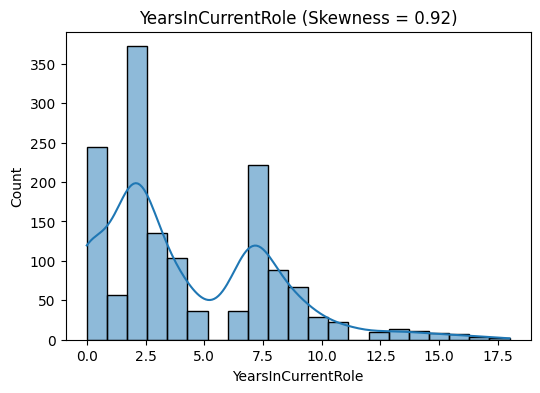

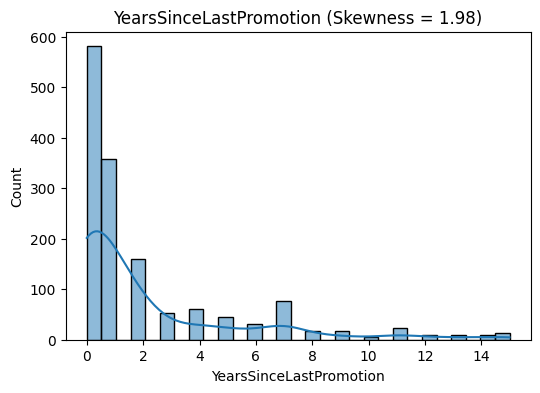

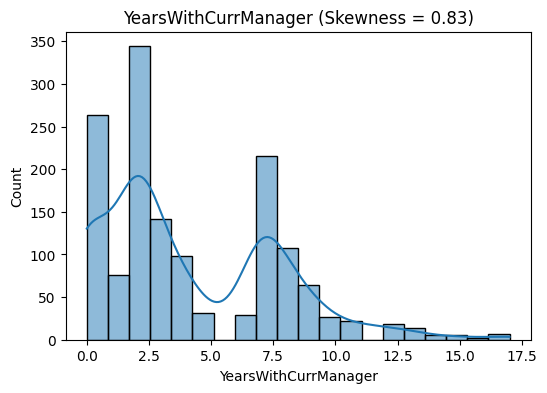

In [35]:
skewness = df.skew(numeric_only=True)

for col in skewness[abs(skewness) > 0.5].index:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Skewness = {skewness[col]:.2f})")
    plt.show()

In [36]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}) # converting Attrition feature into numarical

##Observation
1.Dataset contains 1470 rows and 35 columns.

2.Outliers are present in these features TrainingTimesLastYear,PerformanceRating, MonthlyIncome, YearsSinceLastPromotion, YearsAtCompany, StockOptionLevel, TotalWorkingYears,NumCompaniesWorked, YearsInCurrentRole and YearsWithCurrManager

3.Target feature has an imbalanced data (83.87% and 16.13%)

4.'StandardHours ,'Over18' and  'EmployeeCount' has only 1 unique value it will not contribute for prediction so we can drop these 3 features

5.By observing the mean and 50% the feature 'DistanceFromHome' is right skwed and 'EmployeeNumber' is also little right skwed.
The 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion' and 'YearsWithCurrManager' its 75% amd max values comparionsion is very high, it may containe outliers.

6.DistanceFromHome,MonthlyIncome, NumCompaniesWorked, PerformanceRating, TotalWorkingYears, YearsAtCompany, YearsSinceLastPromotion and YearsWithCurrManager are highly right skewd



###Feature Engineering

In [37]:
df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

In [38]:
df.shape

(1470, 32)

In [39]:
# Columns to check for outliers
columns = ["TrainingTimesLastYear","PerformanceRating", "MonthlyIncome", "YearsSinceLastPromotion", "YearsAtCompany", "StockOptionLevel", "TotalWorkingYears","NumCompaniesWorked", "YearsInCurrentRole", "YearsWithCurrManager"]

# Create a copy of the dataframe
df_clean = df.copy()

for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_clean.shape)

Original Shape: (1470, 32)
Shape After Removing Outliers: (644, 32)


In [40]:
# handling the skwed features
from sklearn.preprocessing import PowerTransformer

# Columns to transform
cols = ['DistanceFromHome','MonthlyIncome','JobLevel','PerformanceRating', 'NumCompaniesWorked', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Initialize transformer
pt = PowerTransformer(method="yeo-johnson")

# Apply transformation
df[cols] = pt.fit_transform(df[cols])

In [41]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [42]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

#for col in cat_cols:
    #df[col] = le.fit_transform(df[col])

In [44]:
#converting object features into numarical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [45]:
#converting object features into numarical features
from sklearn.preprocessing import OneHotEncoder


cat_cols=['BusinessTravel', 'Department', 'EducationField', 'JobRole','MaritalStatus']

encoder = OneHotEncoder(drop='first', sparse_output=False)

for col in cat_cols:
  df[col] = encoder.fit_transform(df[[col]])


In [46]:
df.drop(columns=['EmployeeCount'], inplace=True)

In [47]:
df.shape

(1470, 31)

In [48]:
#feature selection

from sklearn.feature_selection import mutual_info_classif

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_scores)

OverTime                    0.033433
MonthlyIncome               0.033284
JobLevel                    0.031055
Age                         0.022723
YearsInCurrentRole          0.018684
TotalWorkingYears           0.013444
YearsWithCurrManager        0.011212
MaritalStatus               0.010354
HourlyRate                  0.010157
Education                   0.009188
NumCompaniesWorked          0.008125
PerformanceRating           0.007865
StockOptionLevel            0.005854
YearsAtCompany              0.005467
RelationshipSatisfaction    0.005174
BusinessTravel              0.004281
JobRole                     0.004112
PercentSalaryHike           0.003749
TrainingTimesLastYear       0.003691
JobInvolvement              0.002563
MonthlyRate                 0.002478
YearsSinceLastPromotion     0.002216
JobSatisfaction             0.001759
EducationField              0.000000
EnvironmentSatisfaction     0.000000
DistanceFromHome            0.000000
Department                  0.000000
D

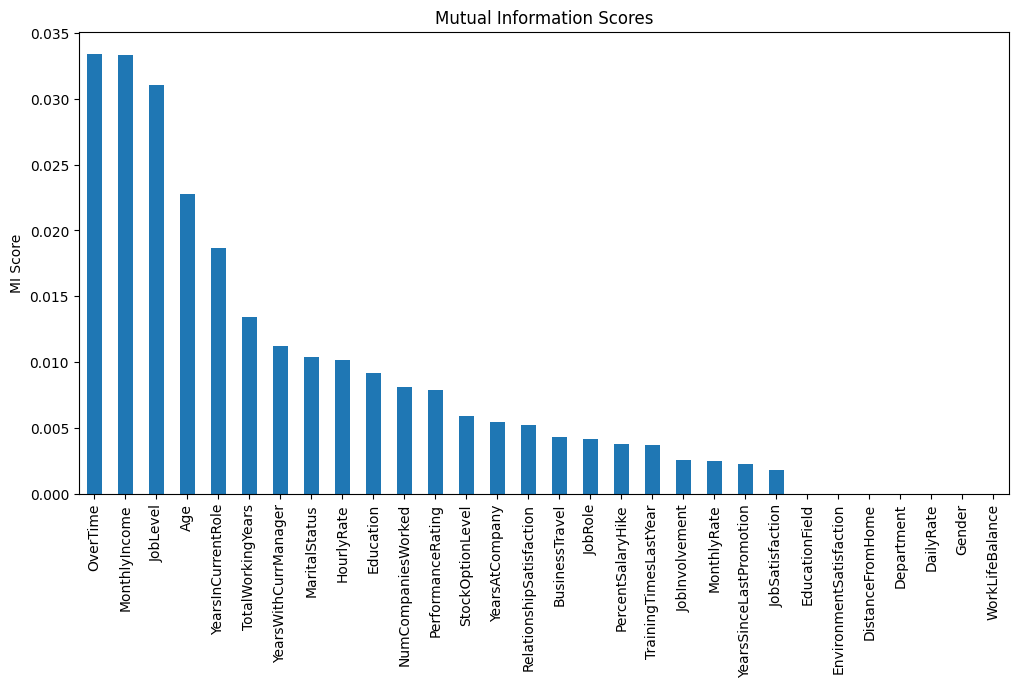

In [49]:
import matplotlib.pyplot as plt

mi_scores.plot(kind="bar", figsize=(12,6))
plt.title("Mutual Information Scores")
plt.ylabel("MI Score")
plt.show()

In [50]:
selected_features = mi_scores[mi_scores > 0].index

X_selected = X[selected_features]

print(selected_features)

Index(['OverTime', 'MonthlyIncome', 'JobLevel', 'Age', 'YearsInCurrentRole',
       'TotalWorkingYears', 'YearsWithCurrManager', 'MaritalStatus',
       'HourlyRate', 'Education', 'NumCompaniesWorked', 'PerformanceRating',
       'StockOptionLevel', 'YearsAtCompany', 'RelationshipSatisfaction',
       'BusinessTravel', 'JobRole', 'PercentSalaryHike',
       'TrainingTimesLastYear', 'JobInvolvement', 'MonthlyRate',
       'YearsSinceLastPromotion', 'JobSatisfaction'],
      dtype='object')


In [51]:
print(X.shape)
print(X_selected.shape)

(1470, 30)
(1470, 23)


#Train Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

#Train a Model

In [53]:
# 2. Globally activate automated metric tracking
#mlflow.autolog()

Accuracy: 0.8707482993197279
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.74      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.81      0.64      0.68       294
weighted avg       0.86      0.87      0.85       294

AUC Score: 0.7701783099319494


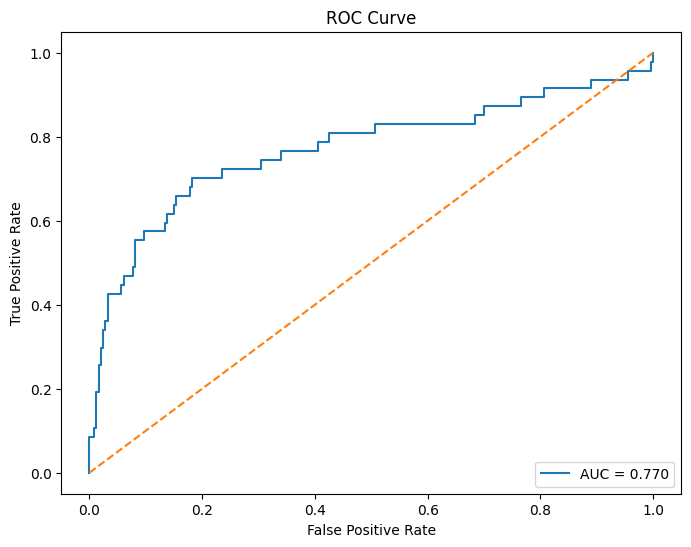

🏃 View run LogisticRegression at: http://127.0.0.1:5001/#/experiments/1/runs/25f9fc07c6f4483298b3dc5108f2dc0b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [54]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
with mlflow.start_run(run_name="LogisticRegression"):
  model = LogisticRegression(max_iter=10000)
  model.fit(X_train, y_train)

  from sklearn.metrics import accuracy_score, classification_report

  #LogisticRegression
  y_pred = model.predict(X_test)

  print("Accuracy:", accuracy_score(y_test, y_pred))

  accuracy = accuracy_score(y_test, y_pred)

  print(classification_report(y_test, y_pred))
  #mlflow.log_metrics({"accuracy": accuracy_score(y_test, y_pred)})

  # Evalution for LogisticRegression
  #ROC
  from sklearn.metrics import roc_curve, roc_auc_score
  y_prob = model.predict_proba(X_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)

  #AUC
  auc_score = roc_auc_score(y_test, y_prob)

  print("AUC Score:", auc_score)

  mlflow.log_param("max_iter", 10000)

  mlflow.log_metric("accuracy", accuracy)
  mlflow.log_metric("auc", auc_score)

  mlflow.sklearn.log_model(
        model,
        name="logistic_regression_model"
  )

  plt.figure(figsize=(8,6))

  plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

  # Diagonal line (random classifier)
  plt.plot([0,1], [0,1], linestyle='--')

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")

  plt.legend(loc="lower right")

  plt.show()

In [55]:
# RandomeForest

from sklearn.ensemble import RandomForestClassifier
with mlflow.start_run(run_name="Random_Forest_Mdl"):
  model2 = RandomForestClassifier(n_estimators=100,max_depth=6,random_state=50)
  model2.fit(X_train, y_train)

  # RandomForest
  y_pred2 = model2.predict(X_test)

  print("Accuracy:", accuracy_score(y_test, y_pred2))

  accuracy = accuracy_score(y_test, y_pred2)

  # Evalution for RandomForest
  #ROC
  from sklearn.metrics import roc_curve, roc_auc_score
  y_prob = model2.predict_proba(X_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)

  #AUC
  auc_score = roc_auc_score(y_test, y_prob)

  print("AUC Score:", auc_score)

  print(classification_report(y_test, y_pred2))

  mlflow.log_param("n_estimators", 100)

  mlflow.log_metric("accuracy", accuracy)
  mlflow.log_metric("auc", auc_score)

  mlflow.sklearn.log_model(
        model,
        name="RandomForest_model"
  )

Accuracy: 0.8639455782312925
AUC Score: 0.7813765182186235
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       247
           1       0.89      0.17      0.29        47

    accuracy                           0.86       294
   macro avg       0.88      0.58      0.61       294
weighted avg       0.87      0.86      0.82       294

🏃 View run Random_Forest_Mdl at: http://127.0.0.1:5001/#/experiments/1/runs/d1ef0268b2d644398ea5861611e03353
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


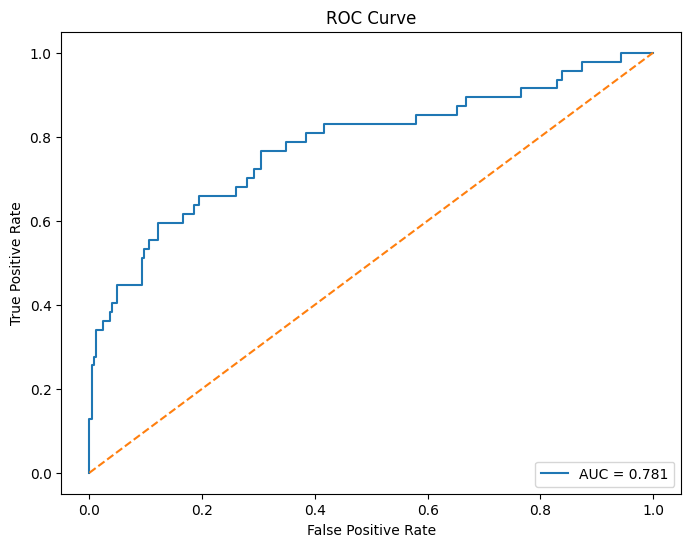

In [56]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")


plt.legend(loc="lower right")

plt.show()

In [57]:
from xgboost import XGBClassifier
with mlflow.start_run(run_name="XGBoost_Advanced"):
  xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=50,
    eval_metric="auc"
  )

  xgb_model.fit(X_train, y_train)
  # XGBoost
  y_pred3 = xgb_model.predict(X_test)

  print("Accuracy:", accuracy_score(y_test, y_pred3))

  accuracy = accuracy_score(y_test, y_pred3)

  # Evalution for XGBoost
  #ROC
  from sklearn.metrics import roc_curve, roc_auc_score
  y_prob = xgb_model.predict_proba(X_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)

  #AUC
  auc_score = roc_auc_score(y_test, y_prob)

  print("AUC Score:", auc_score)

  print(classification_report(y_test, y_pred3))

  mlflow.log_param("n_estimators", 100)

  mlflow.log_metric("accuracy", accuracy)
  mlflow.log_metric("auc", auc_score)
  mlflow.log_param("learning_rate", 0.1)
  mlflow.log_param("max_depth", 6)
  mlflow.log_param("random_state", 50)
  mlflow.log_param("eval_metric", "auc")

  mlflow.sklearn.log_model(
        model,
        name="XGBoost_model"
  )

Accuracy: 0.8571428571428571
AUC Score: 0.780773537772418
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.62      0.28      0.38        47

    accuracy                           0.86       294
   macro avg       0.75      0.62      0.65       294
weighted avg       0.83      0.86      0.83       294

🏃 View run XGBoost_Advanced at: http://127.0.0.1:5001/#/experiments/1/runs/180543bbbd49407b9a31986aec29e0be
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


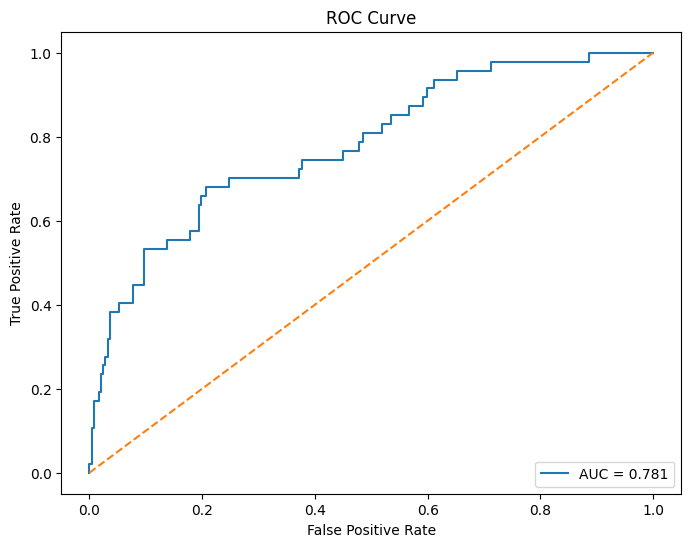

In [58]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

# MLflow

In [59]:
#!pkill -f mlflow
#!pkill -f ngrok


In [60]:
# # 2. Start an MLflow run
# with mlflow.start_run():
#     # Define hyperparameters
#     n_estimators = 100
#     max_depth = 5
#     random_state = 50

# # Log hyperparameters
# mlflow.log_param("n_estimators", n_estimators)
# mlflow.log_param("max_depth", max_depth)
# #mlflow.log_param("learning_rate", learning_rate)
# #mlflow.log_param("eval_metric", eval_metric)
# mlflow.log_param("random_state", random_state)


# # Log metric
# mlflow.log_metric("accuracy", accuracy)

# # Log the trained model artifact
# mlflow.sklearn.log_model(model2, "RandomForest")

# print(f"Run completed! accuracy: {accuracy}")

In [61]:
import mlflow
from mlflow.tracking import MlflowClient
import pandas as pd

# ============================================================
# 1. Connect to the SAME MLflow tracking store/server
# ============================================================

# If you are using the MLflow server:
# mlflow.set_tracking_uri("http://127.0.0.1:5001")

# If your current notebook is directly using SQLite, use:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = MlflowClient()

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())


# ============================================================
# 2. Get the Employee Attrition experiment
# ============================================================

experiment_name = "employee_attrition"

experiment = client.get_experiment_by_name(experiment_name)

if experiment is None:
    raise ValueError(
        f"Experiment '{experiment_name}' was not found."
    )

experiment_id = experiment.experiment_id

print("\nExperiment:")
print(experiment_name)
print("Experiment ID:", experiment_id)


# ============================================================
# 3. Get all runs
# ============================================================

runs_df = mlflow.search_runs(
    experiment_ids=[experiment_id]
)

if runs_df.empty:
    raise ValueError(
        f"No runs found in experiment '{experiment_name}'."
    )


# ============================================================
# 4. Remove unwanted runs
# ============================================================

excluded_run_ids = [
    "1ed512ef4f2049088095c48243a4a13d",
    "747880fe06594e7f9016ef52b8eb9196",
    "61550c12d7164885b601d95f6e018886",
    "66d134f539cd460798183cb81838f4ce",
    "0e8b4d3b21884d52a232b14f569c5b6b",
    "b59326483e96405ea0378366557dc72c",
    "8878ad09bbca43488401b875a92b89ae"
]

runs_df = runs_df[
    ~runs_df["run_id"].isin(excluded_run_ids)
].copy()


# ============================================================
# 5. Find the accuracy column
# ============================================================

possible_accuracy_columns = [
    "metrics.accuracy",
    "metrics.test_accuracy",
    "metrics.accuracy_score_X_test"
]

accuracy_col = next(
    (
        col
        for col in possible_accuracy_columns
        if col in runs_df.columns
    ),
    None
)

if accuracy_col is None:
    raise ValueError(
        "Could not find an accuracy metric in the MLflow runs.\n"
        f"Available columns:\n{runs_df.columns.tolist()}"
    )


# ============================================================
# 6. Remove runs where accuracy is NaN
# ============================================================

runs_df[accuracy_col] = pd.to_numeric(
    runs_df[accuracy_col],
    errors="coerce"
)

runs_df = runs_df.dropna(
    subset=[accuracy_col]
).copy()

if runs_df.empty:
    raise ValueError(
        f"All runs have NaN values for {accuracy_col}."
    )


# ============================================================
# 7. Find the best run
# ============================================================

runs_df = runs_df.sort_values(
    by=accuracy_col,
    ascending=False
)

best_run = runs_df.iloc[0]

best_run_id = best_run["run_id"]

best_run_name = best_run.get(
    "tags.mlflow.runName",
    "Unknown"
)

best_score = best_run[accuracy_col]


print("\n" + "=" * 60)
print("BEST RUN")
print("=" * 60)
print("Run Name :", best_run_name)
print("Run ID   :", best_run_id)
print("Accuracy :", f"{best_score:.4f}")
print("=" * 60)


# ============================================================
# 8. IMPORTANT:
#    Find MLflow 3 Logged Models belonging to this run
# ============================================================

logged_models = mlflow.search_logged_models(
    experiment_ids=[experiment_id],
    output_format="list"
)

# Keep only models created by the winning run
matching_models = [
    model
    for model in logged_models
    if model.source_run_id == best_run_id
]


# ============================================================
# 9. Check whether a logged model exists
# ============================================================

if not matching_models:

    print("\nNo Logged Model found for the winning run.")
    print("\nAvailable Logged Models:")

    for model in logged_models:
        print(
            f"Model ID: {model.model_id} | "
            f"Name: {model.name} | "
            f"Run ID: {model.source_run_id} | "
            f"Status: {model.status}"
        )

    raise ValueError(
        "\nThe best run does not contain a Logged Model. "
        "The model must be logged with mlflow.sklearn.log_model() "
        "before it can be registered."
    )


# ============================================================
# 10. Select a READY logged model
# ============================================================

ready_models = [
    model
    for model in matching_models
    if str(model.status).upper().endswith("READY")
]

if ready_models:
    selected_model = ready_models[0]
else:
    selected_model = matching_models[0]


# ============================================================
# 11. Get the MLflow 3 Model ID
# ============================================================

model_id = selected_model.model_id

model_name = selected_model.name

model_status = selected_model.status


print("\n" + "=" * 60)
print("LOGGED MODEL FOUND")
print("=" * 60)
print("Model Name :", model_name)
print("Model ID   :", model_id)
print("Run ID     :", selected_model.source_run_id)
print("Status     :", model_status)
print("=" * 60)


# ============================================================
# 12. Register the MLflow 3 Logged Model
# ============================================================

registered_model_name = "Best_Attrition_Prediction_Model"

model_uri = f"models:/{model_id}"

print("\nRegistering model...")
print("Model URI:", model_uri)


model_details = mlflow.register_model(
    model_uri=model_uri,
    name=registered_model_name
)


# ============================================================
# 13. Final result
# ============================================================

print("\n" + "=" * 60)
print("SUCCESS")
print("=" * 60)
print(f"Registered Model : {model_details.name}")
print(f"Version          : {model_details.version}")
print(f"Source Model ID  : {model_id}")
print(f"Best Accuracy    : {best_score:.4f}")
print(f"Source Run ID    : {best_run_id}")
print("=" * 60)

MLflow Tracking URI:
sqlite:///mlflow.db

Experiment:
employee_attrition
Experiment ID: 1

BEST RUN
Run Name : LogisticRegression
Run ID   : 25f9fc07c6f4483298b3dc5108f2dc0b
Accuracy : 0.8707

LOGGED MODEL FOUND
Model Name : logistic_regression_model
Model ID   : m-ffe9439bd4594cfea695854deaa14cf3
Run ID     : 25f9fc07c6f4483298b3dc5108f2dc0b
Status     : READY

Registering model...
Model URI: models:/m-ffe9439bd4594cfea695854deaa14cf3

SUCCESS
Registered Model : Best_Attrition_Prediction_Model
Version          : 6
Source Model ID  : m-ffe9439bd4594cfea695854deaa14cf3
Best Accuracy    : 0.8707
Source Run ID    : 25f9fc07c6f4483298b3dc5108f2dc0b


Registered model 'Best_Attrition_Prediction_Model' already exists. Creating a new version of this model...
Created version '6' of model 'Best_Attrition_Prediction_Model'.


In [62]:
mlflow.end_run()